**FULL CNN Pipeline Manually**

In [ ]:
import numpy as np

image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 0],
    [7, 8, 9, 2, 1],
    [1, 3, 5, 7, 9],
    [2, 4, 6, 8, 0]
])

print(image)

[[1 2 3 0 1]
 [4 5 6 1 0]
 [7 8 9 2 1]
 [1 3 5 7 9]
 [2 4 6 8 0]]


In [ ]:
print(image[0][3])

0


In [ ]:
print(image.shape)

(5, 5)


In [ ]:
filter = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

print(filter)

[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]


In [ ]:
#Convolution Operation
region = image[0:3, 0:3]

print(region)
result = region * filter

print(result)
final_value = np.sum(result)

print(final_value)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
[[ 1  0 -3]
 [ 4  0 -6]
 [ 7  0 -9]]
-6


In [ ]:
#FULL CONVOLUTION CODE
import numpy as np

image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 0],
    [7, 8, 9, 2, 1],
    [1, 3, 5, 7, 9],
    [2, 4, 6, 8, 0]
])

filter = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

output = np.zeros((3,3))

for i in range(3):

    for j in range(3):

        region = image[i:i+3, j:j+3]

        result = region * filter

        output[i,j] = np.sum(result)

print(output)

[[ -6.  12.  16.]
 [ -8.   6.  10.]
 [-10.  -2.  10.]]


In [ ]:
import numpy as np

region = np.array([
    [10,10,200],
    [10,10,200],
    [10,10,200]
])

filter = np.array([
    [1,0,-1],
    [1,0,-1],
    [1,0,-1]
])

result = np.sum(region * filter)

print(result)

-570


**CODE PADDING**

In [ ]:
import numpy as np

image = np.array([
    [1,2,3],
    [4,5,6],
    [7,8,9]
])

padded_image = np.pad(image, pad_width=1, mode='constant')

print(padded_image)

[[0 0 0 0 0]
 [0 1 2 3 0]
 [0 4 5 6 0]
 [0 7 8 9 0]
 [0 0 0 0 0]]


**CODE STRIDE**

In [ ]:
import numpy as np

image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 0],
    [7, 8, 9, 2, 1],
    [1, 3, 5, 7, 9],
    [2, 4, 6, 8, 0]
])

filter = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

stride = 2

output = np.zeros((2,2))

for i in range(0, 3, stride):

    for j in range(0, 3, stride):

        region = image[i:i+3, j:j+3]

        result = region * filter

        output[i//stride, j//stride] = np.sum(result)

print(output)

[[ -6.  16.]
 [-10.  10.]]



**CODE MAX POOLING **

In [ ]:
import numpy as np

feature_map = np.array([
    [1, 5, 2, 8],
    [3, 9, 1, 4],
    [0, 6, 7, 2],
    [5, 2, 8, 1]
])

pool_size = 2
stride = 2

output = np.zeros((2,2))

for i in range(0, 4, stride):

    for j in range(0, 4, stride):

        region = feature_map[i:i+2, j:j+2]

        output[i//2, j//2] = np.max(region)

print(output)

[[9. 8.]
 [6. 8.]]


**FULL CNN PIPELINE CODE**

In [ ]:
import numpy as np

# STEP 1 → IMAGE

image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 0],
    [7, 8, 9, 2, 1],
    [1, 3, 5, 7, 9],
    [2, 4, 6, 8, 0]
])

# STEP 2 → FILTER

filter = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

# STEP 3 → EMPTY FEATURE MAP

feature_map = np.zeros((3,3))

# STEP 4 → CONVOLUTION

for i in range(3):

    for j in range(3):

        region = image[i:i+3, j:j+3]

        result = region * filter

        feature_map[i,j] = np.sum(result)

print("Feature Map:")
print(feature_map)

# STEP 5 → ReLU ACTIVATION

relu_output = np.maximum(0, feature_map)

print("\nAfter ReLU:")
print(relu_output)

# STEP 6 → MAX POOLING

pooled_output = np.zeros((1,1))

region = relu_output[0:2, 0:2]

pooled_output[0,0] = np.max(region)

print("\nAfter Pooling:")
print(pooled_output)

Feature Map:
[[ -6.  12.  16.]
 [ -8.   6.  10.]
 [-10.  -2.  10.]]

After ReLU:
[[ 0. 12. 16.]
 [ 0.  6. 10.]
 [ 0.  0. 10.]]

After Pooling:
[[12.]]


**Using keras and tensorflow**

In [ ]:
import tensorflow
from tensorflow import keras

In [ ]:
from keras.datasets import mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [ ]:
print(X_train[0].shape)

(28, 28)


In [ ]:
print(y_train[0])

5


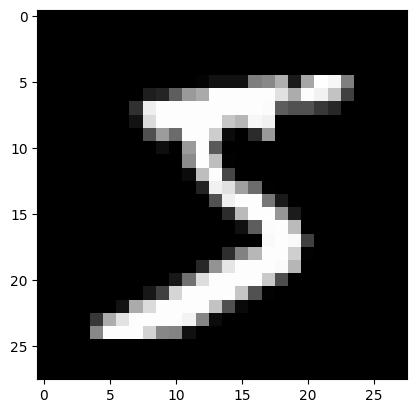

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')

plt.show()

In [ ]:
print(X_train[0].min())
print(X_train[0].max())

0
255


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
X_train = X_train.reshape(60000, 28, 28, 1)

X_test = X_test.reshape(10000, 28, 28, 1)

print(X_train.shape)

print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
from keras import Sequential

model = Sequential()

In [ ]:
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D

In [ ]:
model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu', input_shape=(28,28,1)))

In [ ]:
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

In [ ]:
model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu'))

In [ ]:
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

In [ ]:
model.add(Flatten())

In [ ]:
print(model.output_shape)

(None, 800)


In [ ]:
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,386 (442.91 KB)

 Trainable params: 113,386 (442.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.9485 - loss: 0.1692 - val_accuracy: 0.9762 - val_loss: 0.0763
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9836 - loss: 0.0530 - val_accuracy: 0.9864 - val_loss: 0.0479
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.9884 - loss: 0.0364 - val_accuracy: 0.9880 - val_loss: 0.0413
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9917 - loss: 0.0260 - val_accuracy: 0.9872 - val_loss: 0.0435
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9933 - loss: 0.0203 - val_accuracy: 0.9862 - val_loss: 0.0545
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.9944 - loss: 0.0165 - val_accuracy: 0.9890 - val_loss: 0.0436
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9956 - loss: 0.0130 - val_accuracy: 0.9890 - val_loss: 0.0434
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9965 -

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

# PREDICTION


prediction = model.predict(
    X_test[0].reshape(1,28,28,1)
)

print(prediction)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

print("Actual Digit:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9895 - loss: 0.0421
Test Accuracy: 0.9894999861717224
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
[[1.10804446e-14 1.84817417e-12 3.80689959e-11 1.26605790e-12
  1.08044859e-17 3.24702931e-14 7.41170227e-21 1.00000000e+00
  1.44052061e-13 9.18265908e-09]]
Predicted Digit: 7
Actual Digit: 7


In [ ]:
y_test[0]

np.uint8(7)